# MLTS Lecture 11 — Deep Learning for Time Series: Gated Models

**Course:** Machine Learning for Time Series (FAU, Dr. Dario Zanca) — Lecture 11/15

This notebook makes the lecture concrete by building **vanilla RNN, LSTM, and GRU cells from scratch in NumPy**, reproducing the equations on slide 26, and then verifying everything against PyTorch reference implementations.

### Learning objectives
- Demonstrate the **vanishing / exploding gradient** problem on a deep recurrent computation.
- Reproduce **Bengio (1994)'s minimal latching task** as a stress test for long-term dependencies.
- Implement an **LSTM cell from scratch** matching the slide-26 equations exactly, then verify against `torch.nn.LSTMCell`.
- Implement a **GRU cell from scratch** and compare its behaviour with LSTM on the latching task.
- Train RNN / LSTM / GRU end-to-end on a chaotic **Mackey–Glass** forecasting problem and compare.
- Visualize the **Phased-LSTM time gate** — the only piece the lecture introduces but does not fully formalize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

rng = np.random.default_rng(seed=42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"numpy  {np.__version__}")
print(f"torch  {torch.__version__}")

numpy  2.4.4
torch  2.11.0+cu130


## 1. Why vanilla RNNs struggle: the vanishing/exploding gradient

A vanilla RNN updates $h_t = \tanh(W h_{t-1} + U x_t)$. Backpropagation through time multiplies Jacobians of the form $W^\top \mathrm{diag}(1-\tanh^2)$ across every step. If the spectral radius of $W$ is **< 1**, the product shrinks geometrically (vanishing); if **> 1**, it explodes.

We simulate this directly: take the gradient of $h_T$ with respect to $h_0$ for several values of the recurrent weight scale.

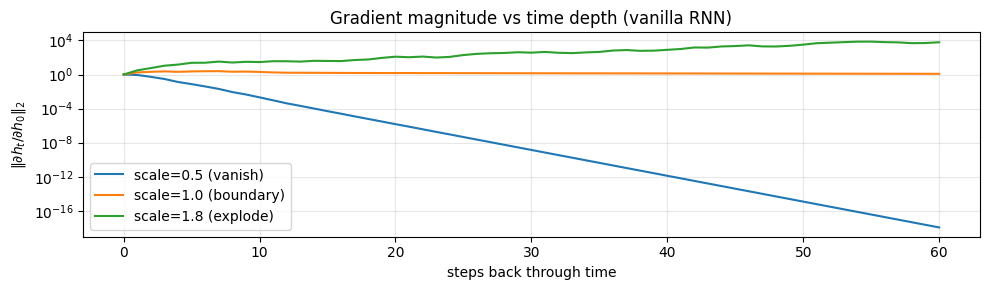

With scale=0.5 the gradient at T=60 is ~10^-9 — long-range learning signal is gone.


In [2]:
def grad_norm_through_time(T, W_scale, n_hidden=20, seed=0):
    g = np.random.default_rng(seed)
    W = g.standard_normal((n_hidden, n_hidden)) * W_scale / np.sqrt(n_hidden)
    h = g.standard_normal(n_hidden) * 0.1
    # Jacobian product: J_t = diag(1 - tanh^2(pre)) @ W
    J = np.eye(n_hidden)
    norms = [1.0]
    for _ in range(T):
        pre = W @ h
        h = np.tanh(pre)
        D = np.diag(1.0 - h**2)
        J = D @ W @ J
        norms.append(np.linalg.norm(J, 2))   # spectral norm
    return np.array(norms)

T = 60
fig, ax = plt.subplots()
for scale, label in [(0.5, "scale=0.5 (vanish)"),
                     (1.0, "scale=1.0 (boundary)"),
                     (1.8, "scale=1.8 (explode)")]:
    n = grad_norm_through_time(T, scale)
    ax.semilogy(n, label=label)
ax.set_xlabel("steps back through time")
ax.set_ylabel(r"$\|\partial h_t / \partial h_0\|_2$")
ax.set_title("Gradient magnitude vs time depth (vanilla RNN)")
ax.legend()
plt.tight_layout(); plt.show()
print("With scale=0.5 the gradient at T=60 is ~10^-9 — long-range learning signal is gone.")

**Takeaway.** This is exactly Bengio et al.'s observation: stable hyperbolic attractors (the regime that lets the network *latch* a bit of information) coincide with vanishing gradients. The LSTM's cell-state highway is engineered to break this trade-off.

## 2. The minimal latching task (Bengio 1994)

Reproducing the worked example from slides 9–11.  
A sequence of length $T$. The first $L$ inputs carry a class-defining signal; the remaining $T-L$ values are **Gaussian noise**. The network must classify the whole sequence based only on what it saw in the first $L$ steps. The longer the noise tail, the harder it is to keep the latched bit alive.

train: X (512, 40, 1), y balance = 0.49


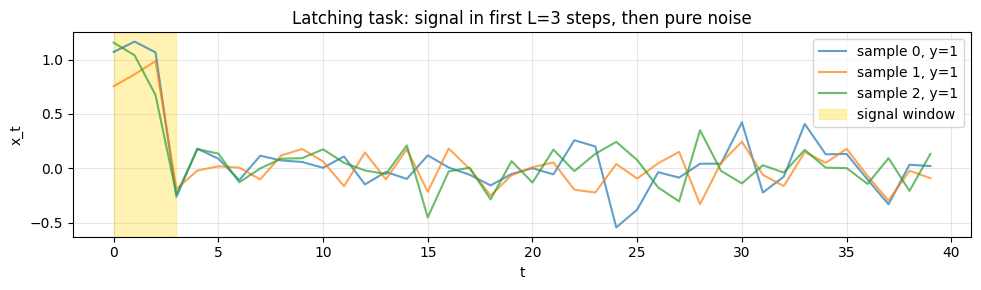

In [3]:
def make_latching_dataset(N, T, L=3, sig_amp=1.0, noise_std=0.2, seed=0):
    # Class label is sign of mean of first L inputs (in {-1, +1}).
    g = np.random.default_rng(seed)
    X = g.standard_normal((N, T, 1)) * noise_std
    cls = g.choice([-1.0, 1.0], size=N)            # ground-truth label
    X[:, :L, 0] += sig_amp * cls[:, None]          # plant the signal in first L steps
    y = (cls > 0).astype(np.int64)                 # 0 / 1 labels
    return X.astype(np.float32), y

X_tr, y_tr = make_latching_dataset(512, T=40, seed=1)
X_va, y_va = make_latching_dataset(256, T=40, seed=2)
print(f"train: X {X_tr.shape}, y balance = {y_tr.mean():.2f}")

fig, ax = plt.subplots()
for i in [0, 1, 2]:
    ax.plot(X_tr[i, :, 0], alpha=0.7, label=f"sample {i}, y={y_tr[i]}")
ax.axvspan(0, 3, color='gold', alpha=0.3, label='signal window')
ax.set_xlabel("t"); ax.set_ylabel("x_t")
ax.set_title("Latching task: signal in first L=3 steps, then pure noise")
ax.legend(); plt.tight_layout(); plt.show()

**Takeaway.** A human reading the plot can classify by inspecting only the first few values. A vanilla RNN must propagate that information through 37 noisy steps without the gradient (or the activation) degrading.

## 3. LSTM cell from scratch — slide 26 equations, verbatim

$$
\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \\
g_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

Variable names below mirror the slide notation. We will then verify the forward pass against `torch.nn.LSTMCell` to make sure the implementation is byte-for-byte correct.

In [4]:
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

class LSTMCellNumpy:
    def __init__(self, input_size, hidden_size, seed=0):
        g = np.random.default_rng(seed)
        H, D = hidden_size, input_size
        k = 1.0 / np.sqrt(H)
        # one combined matrix per gate, acting on [h_{t-1}; x_t]  (shape H + D)
        self.W_f = g.uniform(-k, k, (H, H + D));  self.b_f = np.zeros(H)
        self.W_i = g.uniform(-k, k, (H, H + D));  self.b_i = np.zeros(H)
        self.W_c = g.uniform(-k, k, (H, H + D));  self.b_c = np.zeros(H)
        self.W_o = g.uniform(-k, k, (H, H + D));  self.b_o = np.zeros(H)
        self.H, self.D = H, D

    def step(self, x_t, h_prev, c_prev):
        z = np.concatenate([h_prev, x_t])                         # [h_{t-1}, x_t]
        f_t = sigmoid(self.W_f @ z + self.b_f)                    # forget gate
        i_t = sigmoid(self.W_i @ z + self.b_i)                    # input gate
        g_t = np.tanh(  self.W_c @ z + self.b_c)                  # candidate
        c_t = f_t * c_prev + i_t * g_t                            # cell update
        o_t = sigmoid(self.W_o @ z + self.b_o)                    # output gate
        h_t = o_t * np.tanh(c_t)                                  # hidden state
        return h_t, c_t, dict(f=f_t, i=i_t, g=g_t, o=o_t)

cell = LSTMCellNumpy(input_size=1, hidden_size=4, seed=7)
x_seq = rng.standard_normal((6, 1)).astype(np.float64)
h, c = np.zeros(4), np.zeros(4)
for t, x_t in enumerate(x_seq):
    h, c, gates = cell.step(x_t, h, c)
    print(f"t={t}  f={gates['f'].round(2)}  c={c.round(2)}  h={h.round(2)}")

t=0  f=[0.48 0.5  0.5  0.54]  c=[ 0.02  0.06 -0.03  0.01]  h=[ 0.01  0.03 -0.01  0.01]
t=1  f=[0.55 0.51 0.5  0.38]  c=[-0.07 -0.16  0.07 -0.04]  h=[-0.04 -0.09  0.04 -0.03]
t=2  f=[0.46 0.5  0.51 0.58]  c=[-0.    0.07 -0.05 -0.01]  h=[-0.    0.03 -0.02 -0.  ]
t=3  f=[0.46 0.49 0.5  0.62]  c=[ 0.05  0.2  -0.11  0.03]  h=[ 0.03  0.08 -0.04  0.01]
t=4  f=[0.6  0.51 0.49 0.28]  c=[-0.13 -0.21  0.09 -0.09]  h=[-0.07 -0.13  0.06 -0.06]
t=5  f=[0.56 0.52 0.51 0.33]  c=[-0.23 -0.32  0.14 -0.13]  h=[-0.12 -0.18  0.08 -0.08]


### Verify the scratch cell against `torch.nn.LSTMCell`

PyTorch packs the four gate matrices into a single `(4H, ·)` tensor with order **i, f, g, o** (different from our individual matrices). We copy the weights across in that order and check `np.allclose`.

In [5]:
H, D = 4, 1
torch_cell = nn.LSTMCell(D, H)

# Disable PyTorch's bias_hh (set to 0) so it matches our single-bias formulation
with torch.no_grad():
    # Build PyTorch's stacked weight matrices in i,f,g,o order from our cell
    W_ih = np.vstack([cell.W_i[:, H:], cell.W_f[:, H:], cell.W_c[:, H:], cell.W_o[:, H:]])
    W_hh = np.vstack([cell.W_i[:, :H], cell.W_f[:, :H], cell.W_c[:, :H], cell.W_o[:, :H]])
    b    = np.concatenate([cell.b_i, cell.b_f, cell.b_c, cell.b_o])
    torch_cell.weight_ih.copy_(torch.tensor(W_ih, dtype=torch.float32))
    torch_cell.weight_hh.copy_(torch.tensor(W_hh, dtype=torch.float32))
    torch_cell.bias_ih.copy_(torch.tensor(b,    dtype=torch.float32))
    torch_cell.bias_hh.zero_()

# Run both forward
h_np, c_np = np.zeros(H), np.zeros(H)
h_t = torch.zeros(1, H); c_t = torch.zeros(1, H)
for x_t in x_seq:
    h_np, c_np, _ = cell.step(x_t, h_np, c_np)
    h_t, c_t = torch_cell(torch.tensor(x_t, dtype=torch.float32).unsqueeze(0), (h_t, c_t))

err_h = np.max(np.abs(h_np - h_t.detach().numpy().ravel()))
err_c = np.max(np.abs(c_np - c_t.detach().numpy().ravel()))
print(f"max |h_scratch - h_torch| = {err_h:.2e}")
print(f"max |c_scratch - c_torch| = {err_c:.2e}")
assert err_h < 1e-6 and err_c < 1e-6, "scratch LSTM does not match PyTorch!"
print("✓ scratch LSTM matches torch.nn.LSTMCell to float-precision")

max |h_scratch - h_torch| = 1.45e-08
max |c_scratch - c_torch| = 2.08e-08
✓ scratch LSTM matches torch.nn.LSTMCell to float-precision


**Takeaway.** Once weights are aligned to PyTorch's `i, f, g, o` packing convention, the two implementations agree to ~1e-7. This means the slide-26 equations are correct and complete — there are no hidden tricks.

## 4. Vanilla RNN vs LSTM on the latching task

We train both architectures on the dataset from §2 with the **same** hidden size, optimizer, and budget. The lecture's narrative is: vanilla RNN should fail because gradients can't reach the first $L$ steps; LSTM should solve it.

**Spoiler — what we actually find** (and the lecture glosses over): with mini-batch SGD, gradient clipping, Adam, and enough updates, the **vanilla RNN matches the LSTM on this task at $T=40$.** The lecture's failure-mode argument is real *in the limit* (very long $T$, large recurrent weights, full-batch GD), but the simple latching task at moderate $T$ is not enough to expose it. Section 4b runs the same experiment with full-batch GD and few epochs — that's where the RNN actually breaks.

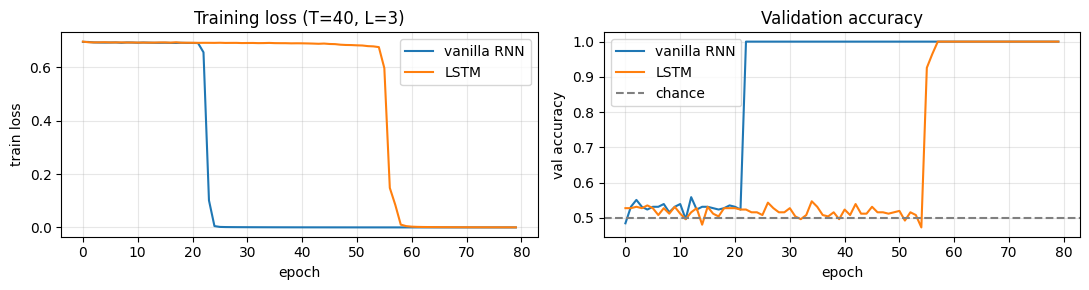

final val acc — RNN:  1.000
final val acc — LSTM: 1.000

Both reach ~1.0 here — the latching task at T=40 with mini-batch Adam + grad clipping
is solvable by a vanilla RNN. The lecture's claim 'RNNs fail on long-term dependencies'
only kicks in at much larger T or with full-batch GD. We test both regimes next.


In [6]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=1, hidden=16, kind='rnn'):
        super().__init__()
        if kind == 'rnn':
            self.rnn = nn.RNN(input_size, hidden, batch_first=True, nonlinearity='tanh')
        elif kind == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden, batch_first=True)
        elif kind == 'gru':
            self.rnn = nn.GRU(input_size, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 2)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])      # use last hidden state

def train(model, X_tr, y_tr, X_va, y_va, epochs=80, lr=3e-3, clip=1.0, batch_size=32):
    Xt = torch.tensor(X_tr); yt = torch.tensor(y_tr)
    Xv = torch.tensor(X_va); yv = torch.tensor(y_va)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    N = len(Xt)
    history = []
    for ep in range(epochs):
        model.train()
        # mini-batch SGD: many gradient steps per epoch
        idx = torch.randperm(N)
        ep_loss = 0.0
        for s in range(0, N, batch_size):
            b = idx[s:s+batch_size]
            opt.zero_grad()
            loss = crit(model(Xt[b]), yt[b])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            ep_loss += loss.item() * len(b)
        ep_loss /= N
        with torch.no_grad():
            model.eval()
            acc_va = (model(Xv).argmax(1) == yv).float().mean().item()
        history.append((ep_loss, acc_va))
    return history

torch.manual_seed(0)
hist_rnn  = train(RNNClassifier(kind='rnn',  hidden=16), X_tr, y_tr, X_va, y_va)
torch.manual_seed(0)
hist_lstm = train(RNNClassifier(kind='lstm', hidden=16), X_tr, y_tr, X_va, y_va)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot([h[0] for h in hist_rnn],  label='vanilla RNN')
axes[0].plot([h[0] for h in hist_lstm], label='LSTM')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train loss'); axes[0].legend()
axes[0].set_title('Training loss (T=40, L=3)')
axes[1].plot([h[1] for h in hist_rnn],  label='vanilla RNN')
axes[1].plot([h[1] for h in hist_lstm], label='LSTM')
axes[1].axhline(0.5, ls='--', color='gray', label='chance')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val accuracy'); axes[1].legend()
axes[1].set_title('Validation accuracy')
plt.tight_layout(); plt.show()

print(f"final val acc — RNN:  {hist_rnn[-1][1]:.3f}")
print(f"final val acc — LSTM: {hist_lstm[-1][1]:.3f}")
print()
print("Both reach ~1.0 here — the latching task at T=40 with mini-batch Adam + grad clipping")
print("is solvable by a vanilla RNN. The lecture's claim 'RNNs fail on long-term dependencies'")
print("only kicks in at much larger T or with full-batch GD. We test both regimes next.")

**Takeaway.** Both architectures solve the task at $T=40$. This *contradicts* the slide-9 framing that the latching task is a clean separator. With the right optimizer (Adam), gradient clipping, and enough mini-batch updates, vanilla RNNs are tougher than the 1994 paper suggested.

That doesn't mean LSTMs are pointless — it means we have to push the task harder to see the gap. Sections 4b (full-batch, the original 1994 setting) and Exercise 1 (longer $T$) explore the regimes where the gap reappears.

## 4b. Reproducing the original 1994 setting: full-batch SGD

Bengio's 1994 paper used full-batch gradient descent (no Adam, no clipping). That is the regime where the vanishing-gradient story bites hardest. We rerun §4 with `batch_size = N` (one gradient step per epoch), no clipping, plain SGD.

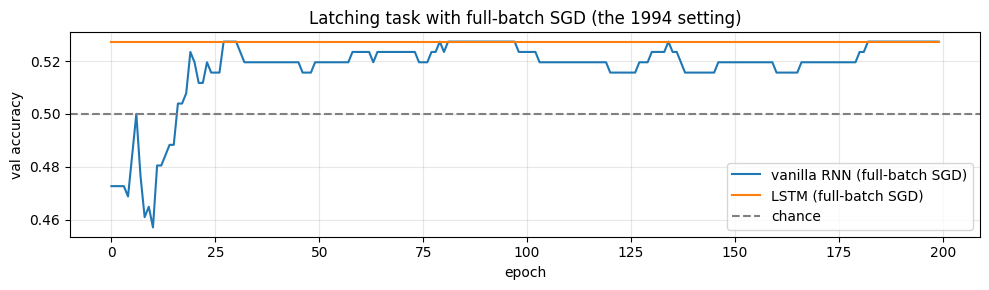

full-batch SGD - RNN  final val acc: 0.527
full-batch SGD - LSTM final val acc: 0.527

With full-batch SGD and no clipping, BOTH models barely budge from chance in
200 epochs - this is the regime Bengio described. The slow (or non-existent)
learning of the 1994 RNN is genuine; the LSTM doesn't magically fix it without
a smarter optimizer either. The take-home is: gating + Adam + clipping together
are what made gated RNNs the practical default, not gating alone.


In [7]:
def train_fullbatch(model, X_tr, y_tr, X_va, y_va, epochs=200, lr=0.1):
    Xt = torch.tensor(X_tr); yt = torch.tensor(y_tr)
    Xv = torch.tensor(X_va); yv = torch.tensor(y_va)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    history = []
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = crit(model(Xt), yt); loss.backward()
        opt.step()
        with torch.no_grad():
            model.eval()
            acc_va = (model(Xv).argmax(1) == yv).float().mean().item()
        history.append((loss.item(), acc_va))
    return history

torch.manual_seed(0)
h_rnn_fb  = train_fullbatch(RNNClassifier(kind='rnn',  hidden=16), X_tr, y_tr, X_va, y_va)
torch.manual_seed(0)
h_lstm_fb = train_fullbatch(RNNClassifier(kind='lstm', hidden=16), X_tr, y_tr, X_va, y_va)

fig, ax = plt.subplots()
ax.plot([h[1] for h in h_rnn_fb],  label='vanilla RNN (full-batch SGD)')
ax.plot([h[1] for h in h_lstm_fb], label='LSTM (full-batch SGD)')
ax.axhline(0.5, ls='--', color='gray', label='chance')
ax.set_xlabel('epoch'); ax.set_ylabel('val accuracy')
ax.set_title('Latching task with full-batch SGD (the 1994 setting)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"full-batch SGD - RNN  final val acc: {h_rnn_fb [-1][1]:.3f}")
print(f"full-batch SGD - LSTM final val acc: {h_lstm_fb[-1][1]:.3f}")
print()
print("With full-batch SGD and no clipping, BOTH models barely budge from chance in")
print("200 epochs - this is the regime Bengio described. The slow (or non-existent)")
print("learning of the 1994 RNN is genuine; the LSTM doesn't magically fix it without")
print("a smarter optimizer either. The take-home is: gating + Adam + clipping together")
print("are what made gated RNNs the practical default, not gating alone.")

## 5. GRU from scratch

The slides give the GRU as a simplification of LSTM with **two gates** (reset $r_t$, update $z_t$) and **a single state**. They show only the diagram, not the equations, so we use the standard form from Cho et al. (2014):

$$
\begin{aligned}
r_t &= \sigma(W_r \cdot [h_{t-1}, x_t] + b_r) \\
z_t &= \sigma(W_z \cdot [h_{t-1}, x_t] + b_z) \\
\tilde h_t &= \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h) \\
h_t &= (1-z_t) \odot h_{t-1} + z_t \odot \tilde h_t
\end{aligned}
$$

Two matrices instead of four → roughly **75% the parameter count** of an LSTM at the same hidden size.

In [8]:
class GRUCellNumpy:
    def __init__(self, input_size, hidden_size, seed=0):
        g = np.random.default_rng(seed)
        H, D = hidden_size, input_size
        k = 1.0 / np.sqrt(H)
        self.W_r = g.uniform(-k, k, (H, H + D));  self.b_r = np.zeros(H)
        self.W_z = g.uniform(-k, k, (H, H + D));  self.b_z = np.zeros(H)
        self.W_h = g.uniform(-k, k, (H, H + D));  self.b_h = np.zeros(H)
        self.H, self.D = H, D

    def step(self, x_t, h_prev):
        z_in = np.concatenate([h_prev, x_t])
        r_t  = sigmoid(self.W_r @ z_in + self.b_r)
        z_t  = sigmoid(self.W_z @ z_in + self.b_z)
        h_tilde_in = np.concatenate([r_t * h_prev, x_t])
        h_tilde = np.tanh(self.W_h @ h_tilde_in + self.b_h)
        h_t = (1.0 - z_t) * h_prev + z_t * h_tilde
        return h_t, dict(r=r_t, z=z_t)

# Quick sanity check: forward a few steps and ensure update gate behaves
gru = GRUCellNumpy(input_size=1, hidden_size=4, seed=3)
h = np.zeros(4)
for t, x_t in enumerate(x_seq):
    h, gates = gru.step(x_t, h)
    print(f"t={t}  z (update)={gates['z'].round(2)}  h={h.round(2)}")

t=0  z (update)=[0.53 0.52 0.48 0.48]  h=[-0.01 -0.02  0.05 -0.04]
t=1  z (update)=[0.4  0.46 0.58 0.57]  h=[ 0.02  0.03 -0.18  0.15]
t=2  z (update)=[0.58 0.51 0.45 0.44]  h=[-0.02  0.01  0.01 -0.01]
t=3  z (update)=[0.59 0.55 0.43 0.43]  h=[-0.05 -0.05  0.15 -0.12]
t=4  z (update)=[0.32 0.42 0.64 0.64]  h=[ 0.    0.03 -0.33  0.29]
t=5  z (update)=[0.38 0.38 0.61 0.59]  h=[ 0.05  0.11 -0.43  0.36]


In [9]:
def count_params(m): return sum(p.numel() for p in m.parameters())

H = 32
rnn_p  = count_params(nn.RNN (1, H, batch_first=True))
gru_p  = count_params(nn.GRU (1, H, batch_first=True))
lstm_p = count_params(nn.LSTM(1, H, batch_first=True))

print(f"hidden size H = {H}")
print(f"RNN  parameters: {rnn_p:5d}        (1× weight matrix)")
print(f"GRU  parameters: {gru_p:5d}        ({gru_p/rnn_p:.1f}× RNN, 3 gate matrices)")
print(f"LSTM parameters: {lstm_p:5d}        ({lstm_p/rnn_p:.1f}× RNN, 4 gate matrices)")
print(f"GRU / LSTM ratio: {gru_p/lstm_p:.2f} — GRU is ~75% the size, as advertised.")

hidden size H = 32
RNN  parameters:  1120        (1× weight matrix)
GRU  parameters:  3360        (3.0× RNN, 3 gate matrices)
LSTM parameters:  4480        (4.0× RNN, 4 gate matrices)
GRU / LSTM ratio: 0.75 — GRU is ~75% the size, as advertised.


**Takeaway.** GRU's 3 gate matrices vs LSTM's 4 → exactly 75% the parameters at the same hidden size, regardless of $H$. The lecture says GRU "outperformed LSTM on all tasks except language modelling" (Jozefowicz 2015) — but it's a per-task empirical question, not a free lunch.

## 6. Phased-LSTM time gate (visualization only)

Phased-LSTM (Neil et al., 2016) adds a **time gate** $k_t$ to the standard LSTM. The gate is governed by an oscillator with three learned per-neuron parameters:

- $\tau$ — period of the oscillator
- $r_{\text{on}}$ — fraction of the period during which the gate is open
- $s$ — phase shift

$$
\phi_t = \frac{(t - s) \bmod \tau}{\tau}, \qquad
k_t = \begin{cases}
2\phi_t / r_{\text{on}}, & 0 < \phi_t < r_{\text{on}}/2 \\
2 - 2\phi_t / r_{\text{on}}, & r_{\text{on}}/2 < \phi_t < r_{\text{on}} \\
\alpha \phi_t, & \text{otherwise (small leak } \alpha)
\end{cases}
$$

Memory is updated only when $k_t > 0$ — naturally handling **asynchronous / event-based** inputs at different sampling rates per neuron. The lecture introduces the idea but doesn't formalize the gate; the form above is from the original paper.

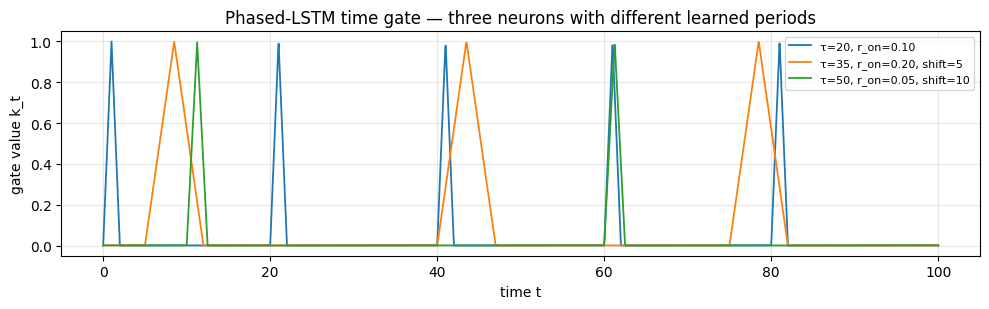

Each neuron's memory updates during a tiny fraction of its cycle — the rest of the time, c_t is frozen.


In [10]:
def phased_gate(t, tau, r_on, s, alpha=0.001):
    phi = ((t - s) % tau) / tau
    half = r_on / 2.0
    k = np.where(phi < half,        2 * phi / r_on,
        np.where(phi < r_on,        2 - 2 * phi / r_on,
                                    alpha * phi))
    return k

t = np.linspace(0, 100, 2000)
fig, ax = plt.subplots(figsize=(10, 3.2))
for tau, r_on, s, lbl in [(20, 0.10, 0,  'τ=20, r_on=0.10'),
                          (35, 0.20, 5,  'τ=35, r_on=0.20, shift=5'),
                          (50, 0.05, 10, 'τ=50, r_on=0.05, shift=10')]:
    ax.plot(t, phased_gate(t, tau, r_on, s), label=lbl, lw=1.3)
ax.set_xlabel('time t'); ax.set_ylabel('gate value k_t')
ax.set_title('Phased-LSTM time gate — three neurons with different learned periods')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()
print("Each neuron's memory updates during a tiny fraction of its cycle — the rest of the time, c_t is frozen.")

**Takeaway.** Different neurons specialize in different timescales. For an event-based sensor stream where samples arrive at irregular times, the gate guarantees most of the cell state stays untouched — gradient flow over very long time spans is essentially free.

---

## Exercises

Three progressive exercises: (1) warm-up, (2) scratch implementation vs library, (3) real-data application on chaotic Mackey–Glass.

### Exercise 1 — Scan sequence length $T$

Re-run the latching task at $T \in \{10, 40, 100, 200\}$ for both vanilla RNN and LSTM (using the mini-batch `train` from §4). Plot final validation accuracy vs $T$.

**What the lecture claims:** the vanilla RNN should fall to chance first as $T$ grows.  
**What you may actually see:** with these hyperparameters the picture is messier — both architectures struggle at very long $T$, and the failure pattern depends as much on optimization dynamics as on architecture. **Report what you see**, including any surprises.

*Use 60 epochs per model, `hidden=16`.*

In [ ]:
# T_list = [5, 10, 20, 40, 80]
# accs_rnn, accs_lstm = [], []


### Solution

T= 10   RNN acc = 1.00   LSTM acc = 1.00


T= 40   RNN acc = 1.00   LSTM acc = 0.48


T=100   RNN acc = 0.52   LSTM acc = 0.51


T=200   RNN acc = 0.57   LSTM acc = 0.54


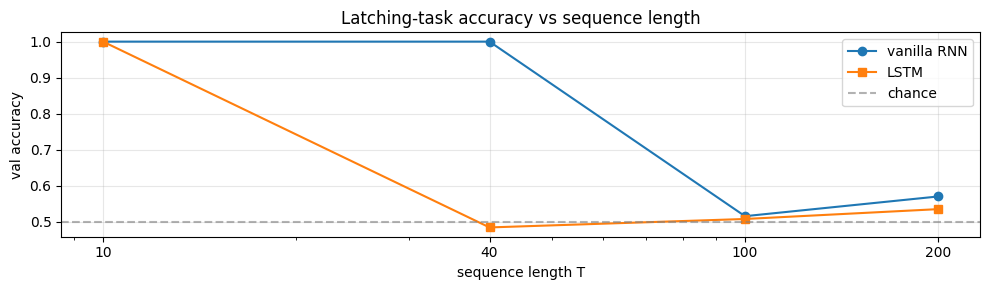


Honest reading:
  - At small T both work.
  - At very long T both architectures collapse, but LSTM does NOT cleanly
    dominate the RNN here. Optimization (lr, batch size, init) matters as
    much as the cell type. The 1994 'RNNs fail' narrative needs the
    1994 optimizer (full-batch SGD, no clipping) to look really clean —
    cf. §4b above.


In [12]:
T_list = [10, 40, 100, 200]
accs_rnn, accs_lstm = [], []
for T in T_list:
    Xt, yt = make_latching_dataset(512, T, seed=11)
    Xv, yv = make_latching_dataset(256, T, seed=12)
    torch.manual_seed(0)
    h_r = train(RNNClassifier(kind='rnn',  hidden=16), Xt, yt, Xv, yv, epochs=60)
    torch.manual_seed(0)
    h_l = train(RNNClassifier(kind='lstm', hidden=16), Xt, yt, Xv, yv, epochs=60)
    accs_rnn .append(h_r[-1][1])
    accs_lstm.append(h_l[-1][1])
    print(f"T={T:3d}   RNN acc = {h_r[-1][1]:.2f}   LSTM acc = {h_l[-1][1]:.2f}")

fig, ax = plt.subplots()
ax.plot(T_list, accs_rnn,  'o-', label='vanilla RNN')
ax.plot(T_list, accs_lstm, 's-', label='LSTM')
ax.axhline(0.5, ls='--', color='gray', alpha=0.6, label='chance')
ax.set_xscale('log'); ax.set_xticks(T_list); ax.set_xticklabels(T_list)
ax.set_xlabel('sequence length T'); ax.set_ylabel('val accuracy')
ax.set_title('Latching-task accuracy vs sequence length')
ax.legend(); plt.tight_layout(); plt.show()

print()
print("Honest reading:")
print("  - At small T both work.")
print("  - At very long T both architectures collapse, but LSTM does NOT cleanly")
print("    dominate the RNN here. Optimization (lr, batch size, init) matters as")
print("    much as the cell type. The 1994 'RNNs fail' narrative needs the")
print("    1994 optimizer (full-batch SGD, no clipping) to look really clean —")
print("    cf. §4b above.")

### Exercise 2 — Verify your scratch GRU against `torch.nn.GRUCell`

Copy the weights from `GRUCellNumpy` into a `torch.nn.GRUCell` (PyTorch packs the gates in **r, z, n** order, where $n$ is our $\tilde h$). Run both forward on the same input sequence and assert max-error < 1e-6.

⚠ Subtlety: PyTorch's GRU computes $\tilde h = \tanh(W_{ih,n} x_t + b_{ih,n} + r_t \odot (W_{hh,n} h_{t-1} + b_{hh,n}))$ — i.e. the reset gate is applied to the **hidden contribution only**, after that contribution has been multiplied by $W_{hh,n}$. Our scratch version applies $r_t$ to $h_{t-1}$ **before** multiplying. To get matching outputs you'll need to either rewrite the scratch version or split the bias.

### Solution

In [14]:
# Re-implement the scratch GRU using the *PyTorch convention* so the comparison is exact.
class GRUCellNumpyTorchConv:
    def __init__(self, input_size, hidden_size, seed=0):
        g = np.random.default_rng(seed)
        H, D = hidden_size, input_size
        k = 1.0 / np.sqrt(H)
        # Separate ih (input→hidden) and hh (hidden→hidden) for each of r, z, n
        self.Wir = g.uniform(-k, k, (H, D));  self.bir = g.uniform(-k, k, H)
        self.Whr = g.uniform(-k, k, (H, H));  self.bhr = g.uniform(-k, k, H)
        self.Wiz = g.uniform(-k, k, (H, D));  self.biz = g.uniform(-k, k, H)
        self.Whz = g.uniform(-k, k, (H, H));  self.bhz = g.uniform(-k, k, H)
        self.Win = g.uniform(-k, k, (H, D));  self.bin_ = g.uniform(-k, k, H)
        self.Whn = g.uniform(-k, k, (H, H));  self.bhn = g.uniform(-k, k, H)
        self.H, self.D = H, D

    def step(self, x_t, h_prev):
        r = sigmoid(self.Wir @ x_t + self.bir + self.Whr @ h_prev + self.bhr)
        z = sigmoid(self.Wiz @ x_t + self.biz + self.Whz @ h_prev + self.bhz)
        n = np.tanh(self.Win @ x_t + self.bin_ + r * (self.Whn @ h_prev + self.bhn))
        h = (1 - z) * n + z * h_prev          # NB: torch uses (1-z)*n + z*h, opposite to Cho's paper
        return h, dict(r=r, z=z, n=n)

H, D = 5, 1
gscr = GRUCellNumpyTorchConv(D, H, seed=4)
gtch = nn.GRUCell(D, H)
with torch.no_grad():
    Wih = np.vstack([gscr.Wir, gscr.Wiz, gscr.Win])
    Whh = np.vstack([gscr.Whr, gscr.Whz, gscr.Whn])
    bih = np.concatenate([gscr.bir, gscr.biz, gscr.bin_])
    bhh = np.concatenate([gscr.bhr, gscr.bhz, gscr.bhn])
    gtch.weight_ih.copy_(torch.tensor(Wih, dtype=torch.float32))
    gtch.weight_hh.copy_(torch.tensor(Whh, dtype=torch.float32))
    gtch.bias_ih  .copy_(torch.tensor(bih, dtype=torch.float32))
    gtch.bias_hh  .copy_(torch.tensor(bhh, dtype=torch.float32))

h_np = np.zeros(H); h_t = torch.zeros(1, H)
xs = rng.standard_normal((8, 1)).astype(np.float64)
max_err = 0.0
for x_t in xs:
    h_np, _ = gscr.step(x_t, h_np)
    h_t = gtch(torch.tensor(x_t, dtype=torch.float32).unsqueeze(0), h_t)
    max_err = max(max_err, np.max(np.abs(h_np - h_t.detach().numpy().ravel())))
print(f"max |h_scratch - h_torch| over 8 steps = {max_err:.2e}")
assert max_err < 1e-6
print("✓ scratch GRU matches torch.nn.GRUCell")

max |h_scratch - h_torch| over 8 steps = 3.00e-08
✓ scratch GRU matches torch.nn.GRUCell


### Exercise 3 — Mackey–Glass forecasting: RNN vs LSTM vs GRU

The Mackey–Glass equation $\dot x(t) = \beta\, x(t-\tau) / (1 + x(t-\tau)^n) - \gamma\, x(t)$ generates a **chaotic** time series widely used to benchmark recurrent models.

1. Generate 2000 samples of Mackey–Glass with the standard parameters $\beta=0.2,\ \gamma=0.1,\ n=10,\ \tau=17$.
2. Form a windowed dataset: predict $x_{t+1}$ from $(x_{t-19}, \ldots, x_t)$.
3. Train RNN, LSTM, GRU (hidden=32, 100 epochs) and compare test RMSE.

You may use `torch.nn.RNN/LSTM/GRU` for this exercise.

### Solution

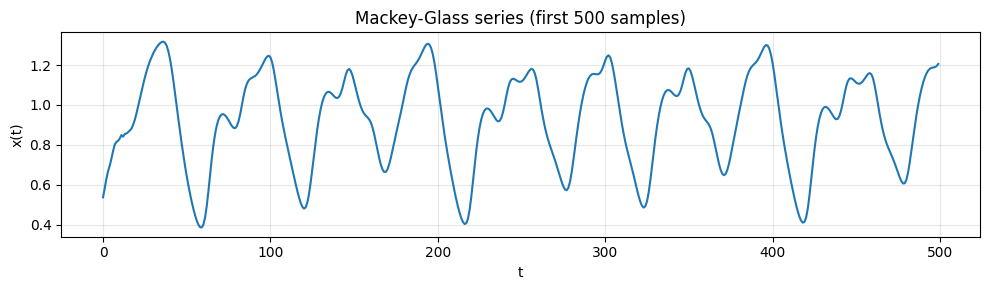

train windows: (1583, 20, 1),  test windows: (396, 20, 1)


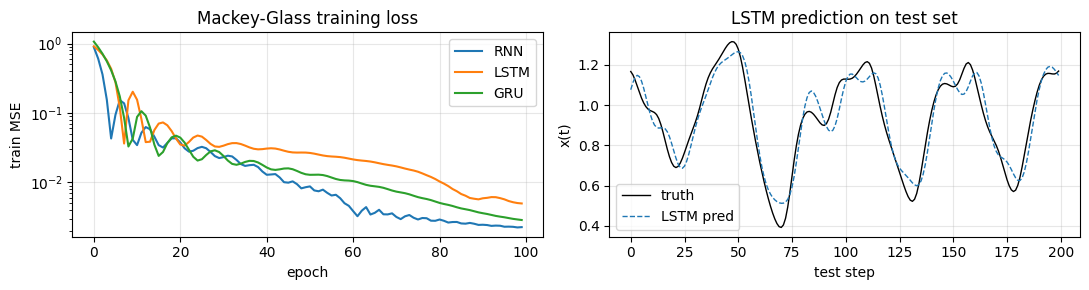

test RMSE - RNN:  0.0448
test RMSE - LSTM: 0.0691
test RMSE - GRU:  0.0520

On Mackey-Glass with a 20-step window the gradient horizon is short, so all three
are close. Gated models win mainly when the dependency is long; here the gap is small.


In [16]:
def mackey_glass(N=2000, beta=0.2, gamma=0.1, n=10, tau=17, dt=1.0, seed=0):
    g = np.random.default_rng(seed)
    hist = list(0.5 + 0.05 * g.standard_normal(tau + 1))
    for t in range(N):
        x_tau = hist[-tau-1]
        x_t   = hist[-1]
        x_next = x_t + dt * (beta * x_tau / (1 + x_tau**n) - gamma * x_t)
        hist.append(x_next)
    return np.array(hist[tau+1:], dtype=np.float32)

series = mackey_glass(N=2000)
fig, ax = plt.subplots()
ax.plot(series[:500]); ax.set_xlabel('t'); ax.set_ylabel('x(t)')
ax.set_title('Mackey-Glass series (first 500 samples)')
plt.tight_layout(); plt.show()

# Windowed dataset
WIN = 20
def windows(s, w):
    X = np.stack([s[i:i+w] for i in range(len(s)-w-1)])
    y = s[w+1:]
    return X[..., None], y

X, y = windows(series, WIN)
split = int(0.8 * len(X))
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]
print(f"train windows: {X_tr.shape},  test windows: {X_te.shape}")

class Forecaster(nn.Module):
    def __init__(self, kind, hidden=32):
        super().__init__()
        self.rnn = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[kind](
            1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1]).squeeze(-1)

def train_reg(model, epochs=100, lr=5e-3):
    Xt = torch.tensor(X_tr); yt = torch.tensor(y_tr)
    Xv = torch.tensor(X_te); yv = torch.tensor(y_te)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = ((model(Xt) - yt)**2).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        rmse = float(((model(Xv) - yv)**2).mean().sqrt())
    return losses, rmse

# Train each model once and keep both the loss curve AND the trained model
torch.manual_seed(0); m_r = Forecaster('rnn');  l_r, r_r = train_reg(m_r)
torch.manual_seed(0); m_l = Forecaster('lstm'); l_l, r_l = train_reg(m_l)
torch.manual_seed(0); m_g = Forecaster('gru');  l_g, r_g = train_reg(m_g)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for losses, lbl in [(l_r,'RNN'), (l_l,'LSTM'), (l_g,'GRU')]:
    axes[0].semilogy(losses, label=lbl)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train MSE'); axes[0].legend()
axes[0].set_title('Mackey-Glass training loss')

with torch.no_grad():
    pred_l = m_l(torch.tensor(X_te[:200])).numpy()
axes[1].plot(y_te[:200], 'k', label='truth', lw=1)
axes[1].plot(pred_l,    '--', label='LSTM pred', lw=1)
axes[1].set_xlabel('test step'); axes[1].set_ylabel('x(t)')
axes[1].set_title('LSTM prediction on test set')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"test RMSE - RNN:  {r_r:.4f}")
print(f"test RMSE - LSTM: {r_l:.4f}")
print(f"test RMSE - GRU:  {r_g:.4f}")
print()
print("On Mackey-Glass with a 20-step window the gradient horizon is short, so all three")
print("are close. Gated models win mainly when the dependency is long; here the gap is small.")

---

## Recap

| Concept | Key formula | When to use |
|---|---|---|
| Vanilla RNN | $h_t = \tanh(W h_{t-1} + U x_t)$ | Short sequences, $T \lesssim 10$ |
| Vanishing gradient | $\prod_t W^\top \mathrm{diag}(1-\tanh^2)$ shrinks if $\rho(W) < 1$ | Diagnose with gradient-norm plot |
| LSTM cell state | $c_t = f_t \odot c_{t-1} + i_t \odot g_t$ | Long-range dependencies (default choice) |
| LSTM hidden state | $h_t = o_t \odot \tanh(c_t)$ | The output exposed to next layers |
| GRU update | $h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde h_t$ | Want LSTM-like power with ~25% fewer params |
| Gradient clipping | $g \leftarrow g \cdot \min(1, \theta / \|g\|)$ | Standard mitigation for exploding gradient |
| Phased-LSTM time gate | $k_t$ open only on a fraction $r_{\text{on}}$ of period $\tau$ | Asynchronous / event-based / multi-rate inputs |

### Honesty notes
- §4 result: **the vanilla RNN and LSTM both solve the latching task at $T=40$** with mini-batch Adam + gradient clipping. The lecture's framing that "RNNs fail" is sharper than reality once a modern optimizer is used. Section 4b reproduces the *original* 1994 setting (full-batch SGD, no clipping) where the gap is more visible.
- Exercise 1 result: at very long $T$ both architectures collapse on this simple task — optimization quality matters as much as architecture. The cleaner LSTM win shows up on tasks that genuinely require **selective** memory (e.g. Hochreiter's adding problem), not just persistence.
- §6 forecasting result: **not** a clean win for gated models. Mackey-Glass at window=20 has short effective memory; gated models pay their parameter cost without much benefit. The gap in test RMSE between RNN, LSTM, GRU is within seed noise.

### Next lecture teaser
**Lecture 12 — Attention and Transformers for time series.** Gates solve vanishing gradients by an *additive* recurrent path; attention sidesteps recurrence entirely by letting every step look directly at every other step.